<a href="https://colab.research.google.com/github/DristiMhrzn/Week-4-image-classification/blob/main/Week5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [37]:
import os
import numpy as np
import random
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.applications.resnet import ResNet152, preprocess_input, decode_predictions
from tensorflow.keras.preprocessing import image

In [38]:
# Load ResNet152 model trained on ImageNet
model = ResNet152(weights="imagenet")

In [39]:
# Dataset folder path
dataset_path = "/content/Dataset"

In [40]:
def process_image(img_path):
    # Load image and resize
    img = image.load_img(img_path, target_size=(224, 224))

    # Convert to array
    img_array = image.img_to_array(img)

    # Expand dimensions
    img_array = np.expand_dims(img_array, axis=0)

    # Preprocess for ResNet
    img_array = preprocess_input(img_array)

    return img, img_array

In [41]:
# Get all valid image files
image_list = [img for img in os.listdir(dataset_path)
              if img.lower().endswith((".jpg", ".jpeg", ".png"))]

# Select random images (max 10)
selected_images = random.sample(image_list, min(10, len(image_list)))

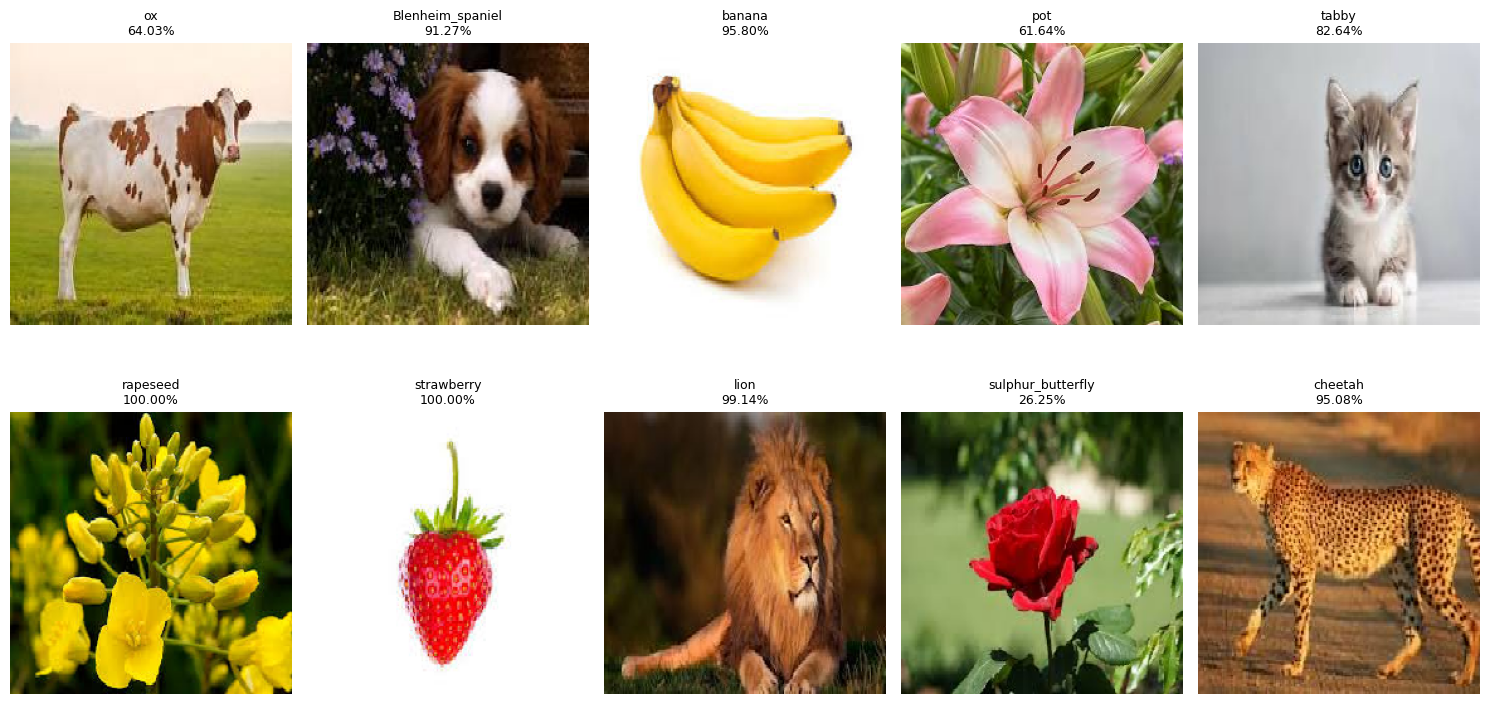

In [47]:
# Dictionary to store prediction summary
prediction_summary = {}

plt.figure(figsize=(15, 8))

for i, file in enumerate(selected_images):
    img_path = os.path.join(dataset_path, file)

    # Process image
    original_img, processed_img = process_image(img_path)

    # Predict
    predictions = model.predict(processed_img, verbose=0)
    decoded = decode_predictions(predictions, top=1)[0][0]

    label = decoded[1]
    confidence = decoded[2] * 100

    # Store summary
    if label in prediction_summary:
        prediction_summary[label] += 1
    else:
        prediction_summary[label] = 1

    # Display image
    plt.subplot(2, 5, i + 1)
    plt.imshow(original_img)
    plt.title(f"{label}\n{confidence:.2f}%", fontsize=9)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [48]:
print("\nPrediction Summary:")
print("-" * 30)

for label, count in prediction_summary.items():
    print(f"{label} : {count} image")


Prediction Summary:
------------------------------
ox : 1 image
Blenheim_spaniel : 1 image
banana : 1 image
pot : 1 image
tabby : 1 image
rapeseed : 1 image
strawberry : 1 image
lion : 1 image
sulphur_butterfly : 1 image
cheetah : 1 image
